# 05 - Multi-Objective Pareto Analysis with difflow

This notebook explores the trade-off between competing objectives (purity, recovery, cost) using Pareto optimization.

## Overview

**The Pareto front** represents the set of solutions where improving one objective necessarily worsens another. These are the "optimal" trade-off solutions.

**Method:** Weighted-sum scalarization with exact gradients enables efficient Pareto front generation.

**difflow advantage:** All computations are JAX-differentiable, enabling gradient-based multi-objective optimization.

In [1]:
import jax
jax.config.update('jax_enable_x64', True)

import jax.numpy as jnp
from jax import grad, jit, value_and_grad
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import optax

# Import difflow for economic analysis
from difflow.economics import separator_cost

plt.style.use('seaborn-v0_8-whitegrid')

Metal device set to: Apple M4 Pro


W0000 00:00:1767575149.746016 18450636 mps_client.cc:510] WARNING: JAX Apple GPU support is experimental and not all JAX functionality is correctly supported!
I0000 00:00:1767575149.753481 18450636 service.cc:145] XLA service 0x6000023a0c00 initialized for platform METAL (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1767575149.753498 18450636 service.cc:153]   StreamExecutor device (0): Metal, <undefined>
I0000 00:00:1767575149.754496 18450636 mps_client.cc:406] Using Simple allocator.
I0000 00:00:1767575149.754503 18450636 mps_client.cc:384] XLA backend will use up to 51539132416 bytes on device 0 for SimpleAllocator.


## 1. Define the Differentiable Model with Cost

In [2]:
def compute_D_pure(element_coeffs, pH, T, conc):
    """Pure JAX function to compute distribution coefficient."""
    a, b, c = element_coeffs['a'], element_coeffs['b'], element_coeffs['c']
    dH = element_coeffs['dH']
    n = element_coeffs['n']
    conc_ref = element_coeffs['conc_ref']
    
    T_ref = 298.15
    R = 8.314
    
    log_D = a + b * pH + c * pH**2
    log_D = log_D + (dH / (R * jnp.log(10))) * (1/T - 1/T_ref)
    log_D = log_D + n * jnp.log10(conc / conc_ref)
    
    return jnp.power(10.0, log_D)

# D2EHPA coefficients from difflow_ree database
ND_COEFFS = {'a': -7.70, 'b': 2.45, 'c': 0.010, 'dH': -1800, 'n': 3.0, 'conc_ref': 0.5}
DY_COEFFS = {'a': -6.78, 'b': 2.80, 'c': 0.010, 'dH': -2400, 'n': 3.0, 'conc_ref': 0.5}

def lle_simulation(pH, OA_ratio, T, conc, F_Nd_feed=0.01, F_Dy_feed=0.01, efficiency=0.95):
    """Run single-stage LLE simulation using pure JAX."""
    D_Nd = compute_D_pure(ND_COEFFS, pH, T, conc)
    D_Dy = compute_D_pure(DY_COEFFS, pH, T, conc)
    
    E_Nd = D_Nd * OA_ratio
    E_Dy = D_Dy * OA_ratio
    
    frac_Nd_org = efficiency * E_Nd / (1.0 + efficiency * E_Nd)
    frac_Dy_org = efficiency * E_Dy / (1.0 + efficiency * E_Dy)
    
    F_Nd_org = F_Nd_feed * frac_Nd_org
    F_Dy_org = F_Dy_feed * frac_Dy_org
    
    purity_Dy = F_Dy_org / (F_Nd_org + F_Dy_org + 1e-10)
    recovery_Dy = F_Dy_org / (F_Dy_feed + 1e-10)
    
    return {'purity_Dy': purity_Dy, 'recovery_Dy': recovery_Dy}

def compute_cost(OA_ratio, conc, F_aq=1.0):
    """Compute annualized cost using difflow.economics."""
    settler_volume = OA_ratio * F_aq * 10  # m³
    capex = separator_cost(jnp.array(settler_volume), "mixer_settler")
    
    extractant_price = 5.0  # $/kg D2EHPA
    makeup_rate = 0.001 * conc  # kg/s (proportional to concentration)
    extractant_cost_annual = makeup_rate * extractant_price * 8000 * 3600  # $/year
    
    crf = 0.1 * (1.1)**10 / ((1.1)**10 - 1)  # Capital recovery factor
    annual_capex = capex * crf
    
    total_annual = annual_capex + extractant_cost_annual
    return total_annual

# Wrapper functions
def purity_fn(params):
    result = lle_simulation(params[0], params[1], params[2], params[3])
    return result['purity_Dy']

def recovery_fn(params):
    result = lle_simulation(params[0], params[1], params[2], params[3])
    return result['recovery_Dy']

def cost_fn(params):
    return compute_cost(params[1], params[3])

## 2. Generate Pareto Front via Weighted-Sum Method

In [3]:
def pareto_optimization(weight, max_iterations=200, learning_rate=0.01):
    """Find Pareto-optimal point for given weight.
    
    Minimizes: weight * (-purity) + (1-weight) * (-recovery)
    """
    bounds_low = jnp.array([1.5, 0.3, 283.0, 0.2])
    bounds_high = jnp.array([4.5, 2.5, 313.0, 1.0])
    
    def objective(params):
        purity = purity_fn(params)
        recovery = recovery_fn(params)
        return weight * (-purity) + (1 - weight) * (-recovery)
    
    def project_to_bounds(params):
        return jnp.clip(params, bounds_low, bounds_high)
    
    optimizer = optax.adam(learning_rate)
    params = jnp.array([3.0, 1.0, 298.15, 0.5])
    opt_state = optimizer.init(params)
    
    def step(params, opt_state):
        loss, grads = value_and_grad(objective)(params)
        updates, opt_state = optimizer.update(grads, opt_state, params)
        params = optax.apply_updates(params, updates)
        params = project_to_bounds(params)
        return params, opt_state, loss
    
    for _ in range(max_iterations):
        params, opt_state, _ = step(params, opt_state)
    
    return {
        'pH': float(params[0]),
        'OA_ratio': float(params[1]),
        'T': float(params[2]),
        'conc': float(params[3]),
        'purity': float(purity_fn(params)),
        'recovery': float(recovery_fn(params)),
        'cost': float(cost_fn(params)),
    }

# Generate Pareto front
print("Generating Pareto front...")
n_points = 40
weights = np.linspace(0.01, 0.99, n_points)

pareto_points = []
for w in weights:
    point = pareto_optimization(w)
    pareto_points.append(point)

print(f"Generated {len(pareto_points)} Pareto-optimal points")

Generating Pareto front...


Generated 40 Pareto-optimal points


In [4]:
# Extract data
purities = np.array([p['purity'] * 100 for p in pareto_points])
recoveries = np.array([p['recovery'] * 100 for p in pareto_points])
costs = np.array([p['cost'] / 1000 for p in pareto_points])  # k$/year
pHs = np.array([p['pH'] for p in pareto_points])
OAs = np.array([p['OA_ratio'] for p in pareto_points])

# Sort by recovery for line plotting
sort_idx = np.argsort(recoveries)
purities_sorted = purities[sort_idx]
recoveries_sorted = recoveries[sort_idx]

## 3. Visualize Pareto Front

Saved: fig4_pareto_front.png/pdf


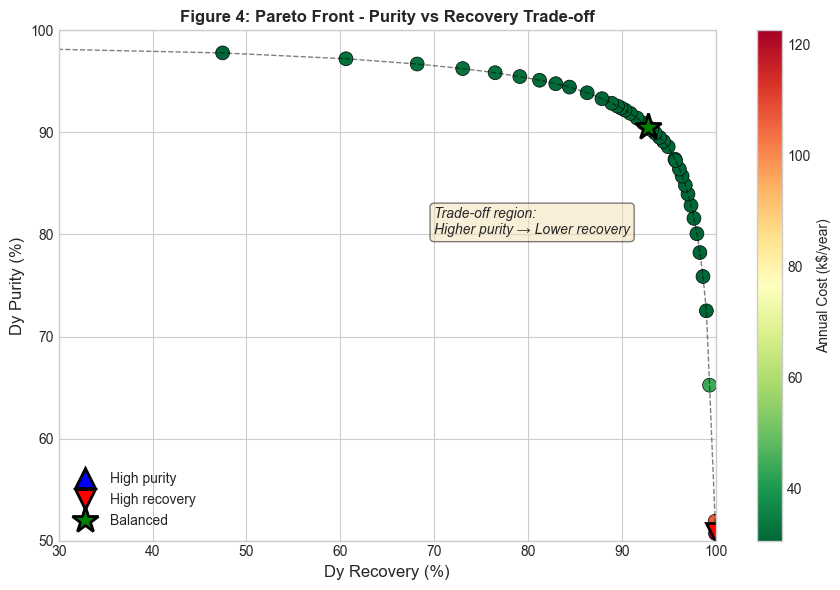

In [5]:
# Plot Pareto front
fig, ax = plt.subplots(figsize=(9, 6))

# Scatter plot colored by cost
sc = ax.scatter(recoveries, purities, c=costs, cmap='RdYlGn_r', 
                s=100, edgecolors='black', linewidth=0.5)
cbar = plt.colorbar(sc, ax=ax)
cbar.set_label('Annual Cost (k$/year)')

# Connect points
ax.plot(recoveries_sorted, purities_sorted, 'k--', alpha=0.5, linewidth=1)

# Identify key points
high_purity_idx = np.argmax(purities)
ax.plot(recoveries[high_purity_idx], purities[high_purity_idx], 
        'b^', markersize=15, markeredgecolor='black', markeredgewidth=2, label='High purity')

high_recovery_idx = np.argmax(recoveries)
ax.plot(recoveries[high_recovery_idx], purities[high_recovery_idx], 
        'rv', markersize=15, markeredgecolor='black', markeredgewidth=2, label='High recovery')

# Balanced (closest to ideal corner)
ideal_dist = (100 - purities)**2 + (100 - recoveries)**2
balanced_idx = np.argmin(ideal_dist)
ax.plot(recoveries[balanced_idx], purities[balanced_idx], 
        'g*', markersize=20, markeredgecolor='black', markeredgewidth=2, label='Balanced')

ax.set_xlabel('Dy Recovery (%)', fontsize=12)
ax.set_ylabel('Dy Purity (%)', fontsize=12)
ax.set_title('Figure 4: Pareto Front - Purity vs Recovery Trade-off', fontsize=12, fontweight='bold')
ax.legend(loc='lower left', fontsize=10)
ax.set_xlim(30, 100)
ax.set_ylim(50, 100)

# Add annotation
ax.annotate('Trade-off region:\nHigher purity → Lower recovery',
            xy=(70, 80), fontsize=10, style='italic',
            bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

plt.tight_layout()

# Save figure
fig.savefig('../manuscript/figures/fig4_pareto_front.png', dpi=300, bbox_inches='tight')
fig.savefig('../manuscript/figures/fig4_pareto_front.pdf', bbox_inches='tight')
print("Saved: fig4_pareto_front.png/pdf")

plt.show()

## 4. Selected Pareto Points Table

In [6]:
# Create table of selected Pareto points
pareto_data = [
    {'Point': 'High purity',
     'Purity': f"{purities[high_purity_idx]:.1f}%",
     'Recovery': f"{recoveries[high_purity_idx]:.1f}%",
     'Cost (k$/yr)': f"{costs[high_purity_idx]:.1f}",
     'pH': f"{pHs[high_purity_idx]:.2f}",
     'O/A': f"{OAs[high_purity_idx]:.2f}"},
    {'Point': 'Balanced',
     'Purity': f"{purities[balanced_idx]:.1f}%",
     'Recovery': f"{recoveries[balanced_idx]:.1f}%",
     'Cost (k$/yr)': f"{costs[balanced_idx]:.1f}",
     'pH': f"{pHs[balanced_idx]:.2f}",
     'O/A': f"{OAs[balanced_idx]:.2f}"},
    {'Point': 'High recovery',
     'Purity': f"{purities[high_recovery_idx]:.1f}%",
     'Recovery': f"{recoveries[high_recovery_idx]:.1f}%",
     'Cost (k$/yr)': f"{costs[high_recovery_idx]:.1f}",
     'pH': f"{pHs[high_recovery_idx]:.2f}",
     'O/A': f"{OAs[high_recovery_idx]:.2f}"},
]

df_pareto = pd.DataFrame(pareto_data)
print("Table 5: Selected Pareto Front Points")
display(df_pareto)

Table 5: Selected Pareto Front Points


,Point,Purity,Recovery,Cost (k$/yr),pH,O/A
0,High purity,98.3%,21.3%,30.7,2.72,0.56
1,Balanced,90.5%,92.8%,30.7,3.31,0.53
2,High recovery,50.7%,100.0%,122.6,3.41,1.36


## 5. Operating Conditions Along Pareto Front

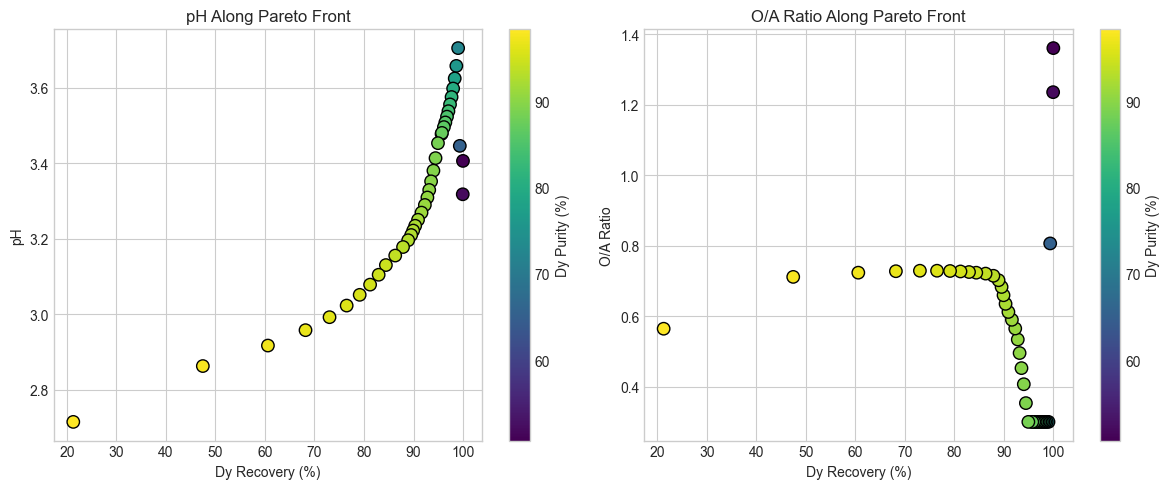


Trend: Lower pH and O/A ratio → Higher purity, Lower recovery


In [7]:
# Plot how operating conditions change along Pareto front
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Left: pH along Pareto
ax1 = axes[0]
sc1 = ax1.scatter(recoveries, pHs, c=purities, cmap='viridis', s=80, edgecolors='black')
cbar1 = plt.colorbar(sc1, ax=ax1)
cbar1.set_label('Dy Purity (%)')
ax1.set_xlabel('Dy Recovery (%)')
ax1.set_ylabel('pH')
ax1.set_title('pH Along Pareto Front')

# Right: O/A ratio along Pareto
ax2 = axes[1]
sc2 = ax2.scatter(recoveries, OAs, c=purities, cmap='viridis', s=80, edgecolors='black')
cbar2 = plt.colorbar(sc2, ax=ax2)
cbar2.set_label('Dy Purity (%)')
ax2.set_xlabel('Dy Recovery (%)')
ax2.set_ylabel('O/A Ratio')
ax2.set_title('O/A Ratio Along Pareto Front')

plt.tight_layout()
plt.show()

print("\nTrend: Lower pH and O/A ratio → Higher purity, Lower recovery")

## 6. Cost vs Performance Trade-off

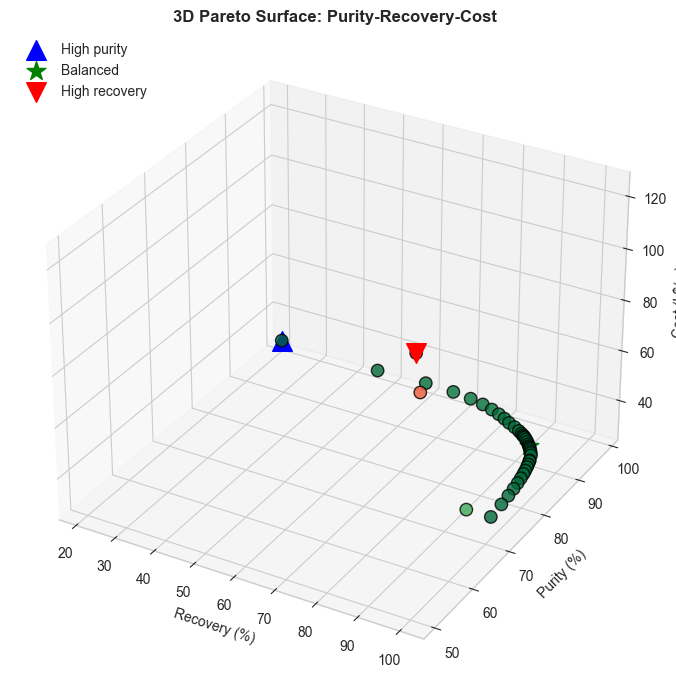

In [8]:
# 3D visualization of purity-recovery-cost
from mpl_toolkits.mplot3d import Axes3D

fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection='3d')

# Plot Pareto surface
sc = ax.scatter(recoveries, purities, costs, c=costs, cmap='RdYlGn_r', 
                s=80, edgecolors='black', alpha=0.8)

# Highlight key points
ax.scatter([recoveries[high_purity_idx]], [purities[high_purity_idx]], 
           [costs[high_purity_idx]], c='blue', s=200, marker='^', label='High purity')
ax.scatter([recoveries[balanced_idx]], [purities[balanced_idx]], 
           [costs[balanced_idx]], c='green', s=200, marker='*', label='Balanced')
ax.scatter([recoveries[high_recovery_idx]], [purities[high_recovery_idx]], 
           [costs[high_recovery_idx]], c='red', s=200, marker='v', label='High recovery')

ax.set_xlabel('Recovery (%)')
ax.set_ylabel('Purity (%)')
ax.set_zlabel('Cost (k$/yr)')
ax.set_title('3D Pareto Surface: Purity-Recovery-Cost', fontsize=12, fontweight='bold')
ax.legend(loc='upper left')

plt.tight_layout()
plt.show()

## Summary

**Key findings from Pareto analysis:**

1. **Clear trade-off** between purity and recovery
   - Cannot maximize both simultaneously
   - Moving along Pareto front: higher purity ↔ lower recovery

2. **Operating condition trends:**
   - Lower pH → higher purity, lower recovery
   - Lower O/A → higher purity, lower recovery

3. **difflow advantage:**
   - Gradient-based Pareto optimization using JAX
   - Cost modeling with difflow.economics
   - Efficient exploration of trade-off space

4. **Decision support:** The Pareto front enables informed trade-off decisions based on process requirements.

**Next:** In notebook 06, we'll quantify how measurement uncertainties propagate to these performance metrics.